# Convolutional Neural Networks and Regularization

This notebook explores Basic DNNs, Regularization, and Convolutional Neural Networks using PyTorch on the MNIST dataset.

In [2]:
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
from torchinfo import summary
from tqdm import tqdm

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Data Preparation

We load the MNIST dataset and split the training set into training and validation sets.
Original TF split: 49800 train, 10200 val, 10000 test.
MNIST total train is 60000. 60000 * 0.17 = 10200. So 60000 - 10200 = 49800. Matches.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load datasets
full_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Split train into train and val
train_size = 49800
val_size = 10200
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}")

# Data loaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:02<00:00, 3.86MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 350kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.02MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.95MB/s]

Train size: 49800, Val size: 10200, Test size: 10000


## Training Helper Functions

In [4]:
def train_model(model, train_loader, val_loader, epochs, lr=0.001, weight_decay=0.0):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    
    history = {
        'sparse_categorical_accuracy': [],
        'val_sparse_categorical_accuracy': [],
        'loss': [],
        'val_loss': []
    }
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        train_loss = running_loss / total
        train_acc = correct / total
        
        # Validation
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        
        history['loss'].append(train_loss)
        history['sparse_categorical_accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_sparse_categorical_accuracy'].append(val_acc)
        
        print(f"Epoch {epoch+1}: Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        
    return history

def evaluate_model(model, test_loader):
    model.eval()
    model.to(device)
    correct = 0
    total = 0
    criterion = nn.CrossEntropyLoss()
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    test_loss = running_loss / total
    test_acc = correct / total
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")
    return test_loss, test_acc

## 1. Basic DNN

In [5]:
class BasicDNN(nn.Module):
    def __init__(self):
        super(BasicDNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 384)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(384, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

model_basic = BasicDNN()
summary(model_basic, input_size=(128, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
BasicDNN                                 [128, 10]                 --
├─Flatten: 1-1                           [128, 784]                --
├─Linear: 1-2                            [128, 384]                301,440
├─ReLU: 1-3                              [128, 384]                --
├─Linear: 1-4                            [128, 128]                49,280
├─ReLU: 1-5                              [128, 128]                --
├─Linear: 1-6                            [128, 10]                 1,290
Total params: 352,010
Trainable params: 352,010
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 45.06
Input size (MB): 0.40
Forward/backward pass size (MB): 0.53
Params size (MB): 1.41
Estimated Total Size (MB): 2.34

In [6]:
all_histories = []

print("Training Basic DNN...")
history_basic = train_model(model_basic, train_loader, val_loader, epochs=10)
all_histories.append(('Basic DNN', history_basic))

Training Basic DNN...


Epoch 1: Loss: 0.3434, Acc: 0.9049, Val Loss: 0.1938, Val Acc: 0.9436


Epoch 2: Loss: 0.1312, Acc: 0.9609, Val Loss: 0.1247, Val Acc: 0.9617


Epoch 3: Loss: 0.0860, Acc: 0.9731, Val Loss: 0.1056, Val Acc: 0.9675


Epoch 4: Loss: 0.0612, Acc: 0.9806, Val Loss: 0.0980, Val Acc: 0.9723


...

Epoch 6: Loss: 0.0311, Acc: 0.9904, Val Loss: 0.0877, Val Acc: 0.9738


Epoch 7: Loss: 0.0272, Acc: 0.9911, Val Loss: 0.0901, Val Acc: 0.9756


Epoch 8: Loss: 0.0213, Acc: 0.9929, Val Loss: 0.0933, Val Acc: 0.9748


Epoch 9: Loss: 0.0160, Acc: 0.9947, Val Loss: 0.0854, Val Acc: 0.9768


Epoch 10: Loss: 0.0149, Acc: 0.9950, Val Loss: 0.0932, Val Acc: 0.9746


## 2. Basic DNN with Regularization

In [7]:
model_reg = BasicDNN() # Same architecture
summary(model_reg, input_size=(128, 1, 28, 28))

print("Training Basic DNN with L2 Regularization...")
# TF L2(0.01) corresponds to weight_decay=0.01 in PyTorch Adam
history_reg = train_model(model_reg, train_loader, val_loader, epochs=10, weight_decay=0.01)
all_histories.append(('Basic DNN reg.', history_reg))

Training Basic DNN with L2 Regularization...


Epoch 1: Loss: 0.4735, Acc: 0.8766, Val Loss: 0.3236, Val Acc: 0.9160


Epoch 2: Loss: 0.3012, Acc: 0.9190, Val Loss: 0.3013, Val Acc: 0.9212


Epoch 3: Loss: 0.2683, Acc: 0.9305, Val Loss: 0.2686, Val Acc: 0.9298


Epoch 4: Loss: 0.2540, Acc: 0.9329, Val Loss: 0.2551, Val Acc: 0.9329


...

Epoch 6: Loss: 0.2368, Acc: 0.9380, Val Loss: 0.2464, Val Acc: 0.9364


Epoch 7: Loss: 0.2320, Acc: 0.9406, Val Loss: 0.2397, Val Acc: 0.9376


Epoch 8: Loss: 0.2267, Acc: 0.9420, Val Loss: 0.2327, Val Acc: 0.9386


Epoch 9: Loss: 0.2257, Acc: 0.9431, Val Loss: 0.2482, Val Acc: 0.9362


Epoch 10: Loss: 0.2227, Acc: 0.9434, Val Loss: 0.2316, Val Acc: 0.9398


In [8]:
evaluate_model(model_reg, test_loader)

Test Loss: 0.2125, Test Accuracy: 0.9442


(0.21246811093091963, 0.9442)

## 3. DNN Reg. Long Training

In [9]:
model_long = BasicDNN() # Same architecture
summary(model_long, input_size=(128, 1, 28, 28))

print("Training Basic DNN with L2 Regularization (25 epochs)...")
history_long = train_model(model_long, train_loader, val_loader, epochs=25, weight_decay=0.01)
all_histories.append(('DNN reg. long training.', history_long))

Training Basic DNN with L2 Regularization (25 epochs)...


Epoch 1: Loss: 0.4656, Acc: 0.8773, Val Loss: 0.3222, Val Acc: 0.9129


Epoch 2: Loss: 0.2958, Acc: 0.9213, Val Loss: 0.2996, Val Acc: 0.9208


Epoch 3: Loss: 0.2639, Acc: 0.9308, Val Loss: 0.2614, Val Acc: 0.9320


Epoch 4: Loss: 0.2503, Acc: 0.9344, Val Loss: 0.2579, Val Acc: 0.9362


...

Epoch 21: Loss: 0.2122, Acc: 0.9478, Val Loss: 0.2206, Val Acc: 0.9465


Epoch 22: Loss: 0.2115, Acc: 0.9480, Val Loss: 0.2245, Val Acc: 0.9441


Epoch 23: Loss: 0.2119, Acc: 0.9466, Val Loss: 0.2271, Val Acc: 0.9413


Epoch 24: Loss: 0.2114, Acc: 0.9485, Val Loss: 0.2206, Val Acc: 0.9469


Epoch 25: Loss: 0.2122, Acc: 0.9477, Val Loss: 0.2174, Val Acc: 0.9469


In [10]:
evaluate_model(model_long, test_loader)

Test Loss: 0.1984, Test Accuracy: 0.9529


(0.19836182790994644, 0.9529)

## 4. CNN

In [11]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Input: (batch, 1, 28, 28)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3) # Output: (batch, 32, 26, 26)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)     # Output: (batch, 32, 13, 13)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3) # Output: (batch, 64, 11, 11)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2)     # Output: (batch, 64, 5, 5)
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(64 * 5 * 5, 10)
        
    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.pool1(x)
        x = self.relu2(self.conv2(x))
        x = self.pool2(x)
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x

model_cnn = CNN()
summary(model_cnn, input_size=(128, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [128, 10]                 --
├─Conv2d: 1-1                            [128, 32, 26, 26]         320
├─ReLU: 1-2                              [128, 32, 26, 26]         --
├─MaxPool2d: 1-3                         [128, 32, 13, 13]         --
├─Conv2d: 1-4                            [128, 64, 11, 11]         18,496
├─ReLU: 1-5                              [128, 64, 11, 11]         --
├─MaxPool2d: 1-6                         [128, 64, 5, 5]           --
├─Flatten: 1-7                           [128, 1600]               --
├─Dropout: 1-8                           [128, 1600]               --
├─Linear: 1-9                            [128, 10]                 16,010
Total params: 34,826
Trainable params: 34,826
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 316.20
Input size (MB): 0.40
Forward/backward pass size (MB): 30.09
Params size (MB): 0.14
Estimated Total Size

In [12]:
print("Training CNN (25 epochs)...")
history_cnn = train_model(model_cnn, train_loader, val_loader, epochs=25)
all_histories.append(('CNN', history_cnn))

Training CNN (25 epochs)...


Epoch 1: Loss: 0.3517, Acc: 0.8952, Val Loss: 0.1145, Val Acc: 0.9668


Epoch 2: Loss: 0.1240, Acc: 0.9627, Val Loss: 0.0856, Val Acc: 0.9747


Epoch 3: Loss: 0.0976, Acc: 0.9707, Val Loss: 0.0668, Val Acc: 0.9810


Epoch 4: Loss: 0.0801, Acc: 0.9748, Val Loss: 0.0582, Val Acc: 0.9839


...

Epoch 21: Loss: 0.0345, Acc: 0.9888, Val Loss: 0.0347, Val Acc: 0.9915


Epoch 22: Loss: 0.0360, Acc: 0.9887, Val Loss: 0.0348, Val Acc: 0.9908


Epoch 23: Loss: 0.0319, Acc: 0.9895, Val Loss: 0.0363, Val Acc: 0.9903


Epoch 24: Loss: 0.0318, Acc: 0.9896, Val Loss: 0.0353, Val Acc: 0.9905


Epoch 25: Loss: 0.0299, Acc: 0.9902, Val Loss: 0.0337, Val Acc: 0.9911


In [13]:
evaluate_model(model_cnn, test_loader)

Test Loss: 0.0247, Test Accuracy: 0.9914


(0.024677721176412887, 0.9914)

## History Comparison

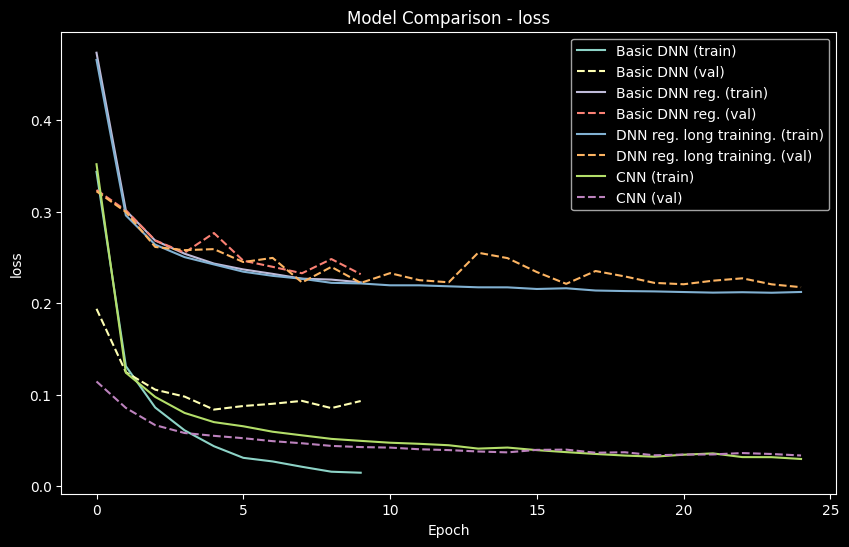

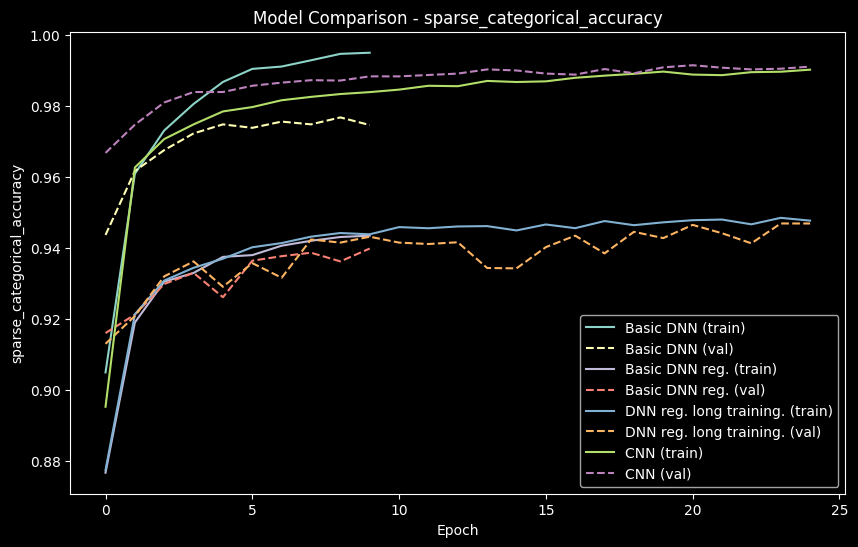

In [14]:
metrics = ['loss', 'sparse_categorical_accuracy']

for metric in metrics:
    plt.figure(figsize=(10, 6))
    for name, history in all_histories:
        plt.plot(history[metric], label=f'{name} (train)')
        plt.plot(history[f'val_{metric}'], '--', label=f'{name} (val)')
    plt.title(f'Model Comparison - {metric}')
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.legend()
    plt.show()